# Tutorial: spatial counterfactuals on Perturb-FISH with `SpatialProp`

Adapted from `pfish_analysis.ipynb` (the Cellina version of this tutorial) to
**SpatialProp** (Sun & Buendia et al.), so the two spatial-counterfactual methods
can be compared on identical held-out cells with the same scoring pipeline. The
scientific question is unchanged: CRISPR knockouts sit on **cancer** cells — do
they produce a predictable transcriptional response in **neighbouring T cells**,
and can a model reproduce it from a tissue-graph counterfactual?

We start from T cells **far** from any perturbed cancer cell and ask what they
would express if their niche were replaced by a perturbed-cancer signature, then
compare against the real **near**-perturbed T cells (the ground truth) — same
edge-swap design as the Cellina notebook (`pfish_prep`/`pfish_graph_utils` build
the identical `idx_control`/`idx_target`/`donor_idx` split).

**How SpatialProp differs mechanically (see markdown notes below for details):**
Cellina encodes a niche as one aggregated vector (`spatial_x`) and its "insertion"
counterfactual *replaces* that vector wholesale with a KO signature (a saturating,
100%-occupancy niche). SpatialProp is a message-passing GNN over the *actual*
spatial graph with per-node features; its native perturbation mechanism ([package
README](https://github.com/) and `spatialprop_eval_loo.py`) instead *adds* a
measured expression shift onto every real cancer cell of the dataset and lets the
GNN propagate it through each T cell's **true** local neighbourhood. We use that
native mechanism (rather than hacking around it) so this notebook reflects how
SpatialProp is actually meant to be deployed — see §4.2 for the exact construction
and an explicit discussion of how this differs from Cellina's saturating
insertion.

**Structure** (mirrors `pfish_analysis.ipynb`): 1. Preprocessing · 2. Training ·
3. Reconstruction sanity check · 4. Counterfactuals (effective-KO selection →
real/random/mean → strong-gene robustness → dose-response) · 5. Interpretation.

Data: `pfish_xenograf_tumor_linearized.h5ad` (154,418 × 154; celltype2 ∈ {cancer,
T cells, other}; NF-κB / innate-immune KO panel) — same file as the Cellina
notebook. Model: SpatialProp GNN trained from scratch on this tissue with the
perturbed-niche T cells (`idx_target`) held out of training (strict OOD, exactly
like the Cellina model).

**Environment:** run this notebook with the `spatial-prop` conda environment
(`conda activate spatial-prop`) — it has `spatial_gnn`, `torch`, `torch_geometric`,
`squidpy`, `decoupler` installed. It does **not** have the `cellina` package, which
is why data prep here uses `pfish_graph_utils.py` (a small, dependency-free copy of
the `pfish_prep.py` graph/context/edge-swap logic) instead of `pfish_prep.py`
directly — see that file's docstring for why.

In [1]:
%matplotlib inline
import os, sys, json as _json
import numpy as np
import pandas as pd

for _d in (os.getcwd(), "/data/a330d/projects/cellina-reproducibility/notebooks/in_vivo"):
    if os.path.exists(os.path.join(_d, "pfish_graph_utils.py")):
        os.chdir(_d); sys.path.insert(0, _d); break
else:
    raise FileNotFoundError("pfish_graph_utils.py not found - run from the in_vivo directory")

import matplotlib.pyplot as plt
import scanpy as sc
import torch
from scipy.stats import pearsonr, wilcoxon
from scipy.spatial import cKDTree

import pfish_graph_utils as pg

from spatial_gnn.api.perturbation_api import train_perturbation_model
from spatial_gnn.datasets.spatial_dataset import SpatialAgingCellDataset
from spatial_gnn.utils.dataset_utils import create_dataloader_from_dataset, load_model_from_path
from spatial_gnn.models.inference import predict

seed = 0
np.random.seed(seed)
rng = np.random.default_rng(seed)

OUT = "./spatialprop_pfish"      # working dir: h5ad files, gnn_datasets cache, trained model
H5 = "pfish_xenograf_tumor_linearized.h5ad"
os.makedirs(OUT, exist_ok=True)

# --- run configuration -------------------------------------------------------
RETRAIN = False        # if True, retrain even when a saved model exists
MAX_EPOCHS = 100        # matches spatialprop_train_loo.py / api_demo.ipynb convention
K_HOP = 2
AUGMENT_HOP = 2
NUM_CELLS_PER_CT_ID = 100   # centers sampled per celltype *during training* (package convention)
LEARNING_RATE = 1e-3
LOSS = "weightedl1"
bw, mn = pg.DEFAULT_BANDWIDTH, pg.DEFAULT_MAX_NEIGHBOURS   # same graph geometry as the Cellina notebook

EXP_NAME = "pfish_spatialprop"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

EFF9 = ["MAP2K2", "IRAK1", "IRF7", "PELI1", "IRF5", "NFKBIA", "LBP", "IRF3", "MAP2K3"]  # see §4.1

/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


device: cuda


## 1. Data preprocessing

`pfish_graph_utils` mirrors `pfish_prep.py`'s graph/context/edge-swap logic
exactly (same Gaussian-kernel bandwidth/max-neighbours), so `idx_control` /
`idx_target` / `donor_idx` below are the **same held-out cells** used in the
Cellina notebook. It does *not* reimplement `pfish_prep.build_features` (Cellina's
aggregated `spatial_x` niche feature) — SpatialProp builds its own graph and
node features internally and never needs it.

In [2]:
print(f"graph geometry: bandwidth={bw}, max_neighbours={mn}")

adata = pg.load_pfish(H5)
adata = pg.filter_cells(adata, max_n_perturb=1)
adata.obs_names_make_unique()
pg.build_graph(adata, bandwidth=bw, max_neighbours=mn)
pg.label_context(adata)
idx_control, idx_target, donor_idx = pg.make_edge_swap_sets(adata, responder="T cells")
adata

graph geometry: bandwidth=250.0, max_neighbours=30
[pfish_graph_utils] dropping 307 cells with n_perturb > 1
[pfish_graph_utils] neighbours/cell: median=30 mean=29.4 (bandwidth=250.0, max=30)
[pfish_graph_utils] context counts:
 context
control      120955
perturbed     33156
Name: count, dtype: int64
[pfish_graph_utils] responder='T cells'  control(niche)=14674  target(niche)=22326  donors=93448 (of which perturbed-cancer=6944)


AnnData object with n_obs × n_vars = 154111 × 154
    obs: 'celltype', 'n_perturb', 'perturbation', 'n_counts', 'celltype2', 'context', 'has_pert_neighbour'
    var: 'n_counts'
    uns: 'celltype2_colors', 'log1p', 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'
    layers: 'log1p', 'counts'
    obsp: 'spatial_connectivities_orig'

In [3]:
obs = adata.obs
print(f"held-out (perturbed-niche) T cells  idx_target : {len(idx_target):>6,}")
print(f"far (control-niche)        T cells  idx_control: {len(idx_control):>6,}")
print("\ncell types:\n", obs["celltype2"].value_counts().to_string())

# far = the (capped) sample of control-niche T cells we predict forward, same seed/cap as the
# Cellina notebook (idx_control is bigger than the cap, so this must match to compare fairly).
far = idx_control if len(idx_control) <= 6000 else rng.choice(idx_control, 6000, replace=False)
print(f"far (sampled far T cells used for counterfactuals): {len(far):,}")

held-out (perturbed-niche) T cells  idx_target : 22,326
far (control-niche)        T cells  idx_control: 14,674

cell types:
 celltype2
cancer     110658
T cells     39201
other        4252
far (sampled far T cells used for counterfactuals): 6,000


### Build the SpatialProp input files

SpatialProp reads `.h5ad` from disk (not an in-memory `AnnData`), needs
`obs['celltype']` (here: `celltype2` — cancer / T cells / other) and
`obsm['spatial']`, and reads node features straight from `adata.X`. Following the
convention in `spatialprop_train_loo.py`/`spatialprop_eval_loo.py`, `X` is set to
`log1p(normalize_total(counts, target_sum=1e4))` (SpatialProp internally
renormalizes each row again to sum to `n_genes` — that double-normalization is the
package's own established convention, kept here for comparability with the other
LOO benchmarks in this repo).

The **training file** excludes `idx_target` entirely (same strict-OOD holdout as
Cellina: the model never sees a perturbed-niche T cell during training). The
**full file** (all cells present) is used for every inference call afterwards —
`idx_target`'s ground-truth expression is read directly from the in-memory
`adata` (no model call needed for that side, see §4.2).

In [4]:
adata_sp = adata.copy()
adata_sp.obs["celltype"] = adata_sp.obs["celltype2"].astype(str)
adata_sp.obs["mouse_id"] = "pfish"
adata_sp.obs["region"] = adata_sp.obs["context"].astype(str)   # optional pass-through metadata only

adata_sp.X = adata_sp.layers["counts"].copy()
sc.pp.normalize_total(adata_sp, target_sum=1e4)
sc.pp.log1p(adata_sp)

adata_sp.obs["is_holdout"] = False
adata_sp.obs.iloc[idx_target, adata_sp.obs.columns.get_loc("is_holdout")] = True

TRAIN_PATH = os.path.join(OUT, "adata_train.h5ad")
TEST_PATH = os.path.join(OUT, "adata_test.h5ad")
PERT_PATH = os.path.join(OUT, "adata_test_perturbed.h5ad")   # overwritten per-condition in §4.2

if RETRAIN or not os.path.exists(TRAIN_PATH):
    adata_sp[~adata_sp.obs["is_holdout"]].copy().write_h5ad(TRAIN_PATH)
    print(f"wrote {TRAIN_PATH}  (train+val, idx_target excluded): "
          f"{(~adata_sp.obs['is_holdout']).sum():,} cells")
if RETRAIN or not os.path.exists(TEST_PATH):
    adata_sp.write_h5ad(TEST_PATH)
    print(f"wrote {TEST_PATH}  (full tissue, for inference): {adata_sp.n_obs:,} cells")

## 2. Training

SpatialProp is a message-passing GNN (GIN, `k_hop=2` layers) trained to predict
each cell's own expression from its k-hop neighbourhood (the center cell's own
feature is always zeroed out before message passing — see
`SpatialAgingCellDataset.extract_khop_subgraphs`), with `augment_hop=2` harvesting
extra subgraphs centered on neighbours of the sampled centers. This is the direct
analogue of Cellina's decoder reconstructing each cell from its niche latent `s`
(and identity `z`) — except SpatialProp reconstructs directly from the graph
rather than from an aggregated `spatial_x` vector, and has no separate
identity/niche split.

**Holdout.** `idx_target` (perturbed-niche T cells) is excluded from
`adata_train.h5ad` entirely — the model never sees a perturbed niche, same strict
out-of-distribution setup as Cellina.

**Train or load.** Trains only if `RETRAIN=True` or no saved model exists;
hyperparameters (`k_hop`, `augment_hop`, `num_cells_per_ct_id=100`,
`loss="weightedl1"`, `lr=1e-3`) match the established convention in
`spatialprop_train_loo.py` / the package's own `api_demo.ipynb`, not tuned
specifically for this dataset.

In [5]:
MODEL_DIR = os.path.join(
    OUT, f"output/{EXP_NAME}",
    f"{EXP_NAME}_expression_{K_HOP}hop_{AUGMENT_HOP}augment_expression_none",
    f"{LOSS}_{LEARNING_RATE:.0e}".replace("-", "n"),
)
MODEL_PATH = os.path.join(MODEL_DIR, "model.pth")
CONFIG_PATH = os.path.join(MODEL_DIR, "config.json")
# resolve to absolute *before* any os.chdir() below -- resolving a relative path again after
# chdir'ing into OUT would double up the OUT prefix (OUT/OUT/output/...).
MODEL_PATH_ABS = os.path.abspath(MODEL_PATH)

need_train = RETRAIN or not (os.path.exists(MODEL_PATH) and os.path.exists(CONFIG_PATH))

# spatial_gnn saves under ./output/... (relative to cwd) regardless of `root`, so run training
# with cwd == OUT to keep all of its cache/output under the same directory as everything else.
_cwd0 = os.getcwd()
try:
    os.chdir(OUT)
    if need_train:
        why = "RETRAIN=True" if os.path.exists(MODEL_PATH) else "no saved model found"
        print(f"training SpatialProp ({why}) ...")
        torch.manual_seed(seed)

        training_args = dict(
            dataset=EXP_NAME,
            file_path=os.path.abspath(os.path.join(_cwd0, TRAIN_PATH)),
            train_ids=["pfish"],
            test_ids=["pfish"],
            exp_name=EXP_NAME,
            k_hop=K_HOP,
            augment_hop=AUGMENT_HOP,
            center_celltypes="all",
            node_feature="expression",
            inject_feature="none",
            learning_rate=LEARNING_RATE,
            loss=LOSS,
            epochs=MAX_EPOCHS,
            normalize_total=True,
            num_cells_per_ct_id=NUM_CELLS_PER_CT_ID,
            predict_celltype=False,
            pool="center",
            do_eval=False,
            device=DEVICE,
        )
        _, gene_names, (model, model_config, trained_model_path) = train_perturbation_model(**training_args)
        print(f"saved model -> {trained_model_path}")
    else:
        model, model_config = load_model_from_path(MODEL_PATH_ABS, DEVICE)
        print(f"loaded existing model from {MODEL_PATH}  (set RETRAIN=True to retrain)")
finally:
    os.chdir(_cwd0)

celltypes_to_index = model_config["celltypes_to_index"]
gene_names = adata_sp.var_names.to_numpy()
print("celltypes_to_index:", celltypes_to_index)

Loaded model configuration:
  - input_dim: 154
  - output_dim: 154
  - inject_dim: 0
  - num_layers: 2
  - method: GIN
  - pool: center
loaded existing model from ./spatialprop_pfish/output/pfish_spatialprop/pfish_spatialprop_expression_2hop_2augment_expression_none/weightedl1_1en03/model.pth  (set RETRAIN=True to retrain)
celltypes_to_index: {'T cells': 0, 'other': 1, 'cancer': 2}


## 3. Reconstruction sanity check

SpatialProp has no interpretable identity/niche latent split to inspect (unlike
Cellina's `z`/`s` UMAPs in §3 of the Cellina notebook) — its only observable output
is the predicted expression itself. As a sanity check before running any
counterfactual, we confirm the model's *unperturbed* reconstruction of far T
cells tracks their real pseudobulk profile (this reconstruction is also exactly
the "pre" baseline used by every counterfactual comparison in §4).

In [6]:
def build_dataset(tag, file_path, center_celltypes, num_cells_per_ct_id, use_perturbed=False,
                   overwrite=False):
    return SpatialAgingCellDataset(
        root=OUT,
        subfolder_name=None,
        dataset_prefix=f"{EXP_NAME}_{tag}",
        target="expression",
        k_hop=K_HOP,
        augment_hop=0,               # no augmentation needed for inference-only centers
        node_feature="expression",
        inject_feature=None,
        num_cells_per_ct_id=num_cells_per_ct_id,
        center_celltypes=center_celltypes,
        whole_tissue=False,
        use_ids=["pfish"],
        raw_filepaths=[os.path.abspath(file_path)],
        celltypes_to_index=celltypes_to_index,
        normalize_total=True,
        perturbation_mask_key="perturbed_input",
        use_perturbed_expression=use_perturbed,
        overwrite=overwrite,
    )


def loader_from(ds, n=1):
    """Build `n` independent DataLoader instances over the same processed dataset.
    `predict()` always zips `dataloader` with `perturbed_dataloader` (never accepts `None`
    for the latter) -- for the no-perturbation sanity check in section 3 we pass the same
    data as both arguments, but as two separate DataLoader objects so the two concurrent
    iterations in `zip()` don't share state."""
    ds.process()
    loaders = []
    for _ in range(n):
        _, loader = create_dataloader_from_dataset(ds, batch_size=1024, shuffle=False,
                                                    num_workers=4, pin_memory=(DEVICE == "cuda"),
                                                    persistent_workers=True)
        loaders.append(loader)
    return loaders[0] if n == 1 else loaders


# built once, reused (unchanged) for every counterfactual condition in section 4
unpert_ds = build_dataset("unpert_T", TEST_PATH, center_celltypes=["T cells"],
                           num_cells_per_ct_id=100_000)
unpert_loader, unpert_loader_dummy = loader_from(unpert_ds, n=2)

adata_result0 = predict(model=model, adata=sc.read_h5ad(TEST_PATH), dataloader=unpert_loader,
                         perturbed_dataloader=unpert_loader_dummy, use_ids=["pfish"], device=DEVICE)
pred_unpert = np.asarray(adata_result0.layers["predicted_unperturbed"])
print("T cells with a prediction:", np.isfinite(pred_unpert).all(axis=1).sum(), "/", (adata.obs['celltype2']=='T cells').sum())

Dataset already exists at:  ./spatialprop_pfish/data/gnn_datasets/pfish_spatialprop_unpert_T_expression_100000per_2hop_0C0aug_200delaunay_expressionFeat_T_NoneInject_subset_pfish


100%|██████████| 79/79 [00:06<00:00, 12.50it/s]
/data/a330d/projects/spatial-prop/src/spatial_gnn/utils/dataset_utils.py:29: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  dataloader = DataLoader(
100%|██████████| 79/79 [00:06<00:00, 11.29it/s]


Starting prediction for 154111 cells, 154 genes


Predicting (unperturbed & perturbed) with tempering...:   0%|          | 0/39 [00:00<?, ?it/s]/data/a330d/projects/spatial-prop/src/spatial_gnn/models/inference.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_expn_batch = torch.tensor(
Predicting (unperturbed & perturbed) with tempering...: 100%|██████████| 39/39 [00:03<00:00, 10.36it/s]


Predicted on 39201 cells
Applied tempering with method 'distribution_renormalize' (batch-wise)
T cells with a prediction: 39201 / 39201


far T cells: real vs SpatialProp-unperturbed-reconstruction pseudobulk Pearson r = 0.824


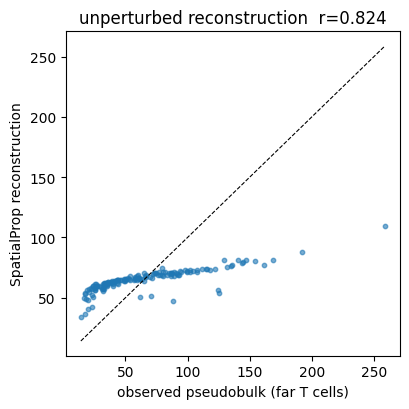

In [7]:
def pn(x):
    """pseudobulk: total-normalize each cell to 1e4, then average across cells."""
    x = np.asarray(x, float)
    return (x / (x.sum(1, keepdims=True) + 1e-8) * 1e4).mean(0)

def lfc(a, b):
    return np.log(a + 1) - np.log(b + 1)

real_far = pn(np.asarray(adata_sp.X)[far])
recon_far = pn(pred_unpert[far])
r_recon = pearsonr(real_far, recon_far)[0]
print(f"far T cells: real vs SpatialProp-unperturbed-reconstruction pseudobulk Pearson r = {r_recon:.3f}")

plt.figure(figsize=(4.2, 4.2))
plt.scatter(real_far, recon_far, s=10, alpha=.6)
lo, hi = min(real_far.min(), recon_far.min()), max(real_far.max(), recon_far.max())
plt.plot([lo, hi], [lo, hi], "k--", lw=.8)
plt.xlabel("observed pseudobulk (far T cells)"); plt.ylabel("SpatialProp reconstruction")
plt.title(f"unperturbed reconstruction  r={r_recon:.3f}"); plt.tight_layout(); plt.show()

## 4. Counterfactuals

### 4.1 Which knockouts can even propagate? (effective-KO selection)

Identical to the Cellina notebook §4.1: a KO can only propagate a signal if it
first changes **its own** cancer cell (depth-matched vs Control-guide cancer
cells, Mann–Whitney + BH-FDR, `direct_sig ≥ 3`). This selection is purely a
property of the **data** (cancer cells' response to their own KO), not of either
model, so it is reused verbatim rather than recomputed. Of 35 KOs, 9 have a real
direct effect — the same `EFF9` list defined in the imports cell above (the
underlying `ko_inventory.csv` this was derived from was produced on a different
machine and isn't part of this checkout; the KO list itself is hardcoded
identically in both notebooks so the two analyses stay on the same 9 KOs).

### 4.2 The counterfactual mechanism — and how it differs from Cellina's insertion

Cellina's "insertion" counterfactual (§4.2 of the Cellina notebook) *replaces* a
far T cell's entire aggregated niche vector (`spatial_x`) with a KO's mean
cancer-cell profile — a saturating, 100%-occupancy niche, chosen because it is
the strongest way to probe direction cleanly with an aggregated-vector encoder.

SpatialProp has no such aggregated vector: each neighbour is its own graph node,
and the model propagates whatever real expression sits on each node through
message passing. Its native, package-documented mechanism for a perturbation
(`create_perturbation_input_matrix` in the package API and in
`spatialprop_eval_loo.py`) is to **add a measured expression shift onto every
real cell of a given type, dataset-wide**, and let the GNN read it off through
each center cell's **true** neighbourhood (however many perturbed-type neighbours
it actually has). We follow that mechanism exactly rather than hacking around it:

- **real** — add KO *k*'s measured direct effect on cancer
  (`mean(KO-guide cancer) − mean(Control-guide cancer)`, computed from the same
  depth-matched log-normalized expression used in §4.1) to **every cancer cell**
  in the tissue, then read off the far T cells' predicted expression.
- **random** — the same construction using a random 300-cell cancer sample in
  place of the KO's own cells (5 draws) — tests whether KO identity matters.
- **mean** — the model-agnostic, data-only baseline reused unchanged from the
  Cellina notebook (§4.3 there): the average observed near-vs-far T-cell shift,
  *not* a model prediction at all (it doesn't touch the GNN in either notebook) —
  the confound free-ride baseline.

Because the injected shift lands on the true fraction of perturbed neighbours a
given far T cell actually has (rather than a synthetic 100%-perturbed niche),
this is architecturally closer to Cellina's weaker **dosed** node-perturbation
variant (§4.6 there) than to its saturating insertion — a real difference between
what the two packages make easy to test, called out explicitly rather than
papered over. `predicted_unperturbed` (§3 above) is the "pre" baseline for every
comparison below, exactly mirroring Cellina's use of its own reconstruction
(`p_recon`) rather than raw real expression, to control for model-intrinsic
bias.

In [8]:
counts = np.asarray(adata.layers["counts"]); ln = np.asarray(adata_sp.X)  # log1p-normalized
pert = obs["perturbation"].astype(str).to_numpy(); nc = obs["n_counts"].to_numpy()
is_cancer = (obs["celltype2"] == "cancer").to_numpy(); is_T = (obs["celltype2"] == "T cells").to_numpy()
pc = is_cancer & (obs["n_perturb"].to_numpy() > 0); uT = is_T & (obs["n_perturb"].to_numpy() == 0)
conn = adata.obsp[pg.CONN_ORIG_KEY].tocsr()

def cd(idx):
    return np.column_stack([np.log1p(nc[idx])])

def match(a, pool):
    Cc = cd(pool); mu, sd = Cc.mean(0), Cc.std(0) + 1e-9
    _, mi = cKDTree((Cc - mu) / sd).query((cd(a) - mu) / sd, k=1); return pool[mi]

def rN(o_, p_, n=10):
    d = np.argsort(-np.abs(o_))[:n]; return pearsonr(o_[d], p_[d])[0]

# --- purely data-derived quantities (identical computation to the Cellina notebook, no model calls) ---
mean_shift = lfc(pn(counts[np.where(uT & (np.asarray(conn.dot(pc.astype(float))).ravel() > 0))[0]]),
                  pn(counts[far]))

OBS = {}
for ko in EFF9:
    kc = pc & (pert == ko)
    near = np.asarray(conn.dot(kc.astype(float))).ravel() > 0
    noth = np.asarray(conn.dot((pc & (pert != ko)).astype(float))).ravel() > 0
    t = np.where(uT & near & ~noth)[0]           # exclusive near-KO-T ground truth
    OBS[ko] = lfc(pn(counts[t]), pn(counts[match(t, far)]))
shared = np.mean([OBS[k] for k in EFF9], axis=0)  # cross-KO average = shared confound
print("computed observed shift for", len(EFF9), "KOs (data-only, reused from the Cellina notebook's own computation)")

computed observed shift for 9 KOs (data-only, reused from the Cellina notebook's own computation)


In [9]:
cancer_control_mask = is_cancer & (pert == "Control")
baseline_cancer = ln[cancer_control_mask].mean(0)
N_GENES = ln.shape[1]

def _normalize_counts(x, eps=1e-8, scale=1e4):
        return x / (x.sum(axis=1, keepdims=True) + eps) * scale

def additive_perturb(cell_mask, delta):
    """adds `delta` (log-normalized units) onto `cell_mask` rows of adata_sp.X, then rescales
    each row to sum to N_GENES -- matches create_perturbation_input_matrix's own convention
    (spatialprop_eval_loo.py) so this stays consistent with the rest of the LOO benchmark suite."""
    X = ln.copy()
    X[cell_mask] = X[cell_mask] + delta[None, :]
    X = np.clip(X, 0, None)
    row_sums = X.sum(1, keepdims=True); row_sums[row_sums == 0] = 1
    return X / row_sums * N_GENES

def run_condition(tag, delta, overwrite):
    """Writes the perturbed test file, builds a freshly-tagged perturbed dataset (unique
    dataset_prefix per condition -- required so SpatialAgingCellDataset's on-disk cache can't
    silently reuse a *different* condition's cached subgraphs), runs inference, and returns the
    predicted-perturbed expression for `far` T cells."""
    adata_pert = sc.read_h5ad(TEST_PATH)
    adata_pert.obsm["perturbed_input"] = additive_perturb(is_cancer, delta)
    adata_pert.write_h5ad(PERT_PATH)

    pert_ds = build_dataset(f"pert_{tag}", PERT_PATH, center_celltypes=["T cells"],
                             num_cells_per_ct_id=100_000, use_perturbed=True, overwrite=overwrite)
    pert_loader = loader_from(pert_ds)

    res = predict(model=model, adata=sc.read_h5ad(TEST_PATH), dataloader=unpert_loader,
                   perturbed_dataloader=pert_loader, use_ids=["pfish"], device=DEVICE)
    return np.asarray(res.layers["predicted_perturbed"])[far]

def to_expr(x):
    """model outputs live in log1p(normalize_total)-then-renormalized-to-N_GENES space (the
    dataset's own training-target space, see SpatialAgingCellDataset.process); undo the log1p so
    `pn`/`lfc` operate on an approximately-linear, counts-like scale -- the same kind of scale as
    `OBS`/`mean_shift` (computed straight from `counts`) so `rN`/`scores` compare like with like."""
    return np.clip(np.expm1(x), 0, None)

def insert(tag, delta, overwrite=False):
    pred_far = run_condition(tag, delta, overwrite)
    #return lfc(pn(to_expr(pred_far)), pn(to_expr(pred_unpert[far])))
    control = _normalize_counts(adata.X[far])
    cf = _normalize_counts(to_expr(pred_far))
    return lfc(pn(cf), pn(control)), cf

REAL, RAND = {}, []
COUNTERFACTUALS = {}
for i, ko in enumerate(EFF9):
    kc = is_cancer & (pert == ko)
    delta = ln[kc].mean(0) - baseline_cancer
    #REAL[ko] = insert(f"real_{ko}", delta, overwrite=False)
    REAL[ko], COUNTERFACTUALS[ko] = insert(f"real_{ko}", delta, overwrite=False)
    print(f"  real[{ko}] done")

for i in range(5):
    idx = rng.choice(np.where(is_cancer)[0], 300, replace=False)
    delta = ln[idx].mean(0) - baseline_cancer
    RAND.append(insert(f"random_{i}", delta)[0])
    print(f"  random[{i}] done")

print("computed SpatialProp real insertion for", len(EFF9), "KOs and", len(RAND), "random draws")

Dataset already exists at:  ./spatialprop_pfish/data/gnn_datasets/pfish_spatialprop_pert_real_MAP2K2_expression_100000per_2hop_0C0aug_200delaunay_expressionFeat_T_NoneInject_perturbed_subset_pfish


100%|██████████| 79/79 [00:06<00:00, 12.60it/s]
/data/a330d/projects/spatial-prop/src/spatial_gnn/utils/dataset_utils.py:29: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  dataloader = DataLoader(


Starting prediction for 154111 cells, 154 genes


Predicting (unperturbed & perturbed) with tempering...:   0%|          | 0/39 [00:00<?, ?it/s]/data/a330d/projects/spatial-prop/src/spatial_gnn/models/inference.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_expn_batch = torch.tensor(
Predicting (unperturbed & perturbed) with tempering...: 100%|██████████| 39/39 [00:03<00:00, 10.34it/s]


Predicted on 39201 cells
Applied tempering with method 'distribution_renormalize' (batch-wise)
  real[MAP2K2] done
Dataset already exists at:  ./spatialprop_pfish/data/gnn_datasets/pfish_spatialprop_pert_real_IRAK1_expression_100000per_2hop_0C0aug_200delaunay_expressionFeat_T_NoneInject_perturbed_subset_pfish


...

Predicted on 39201 cells
Applied tempering with method 'distribution_renormalize' (batch-wise)
  random[3] done
Dataset already exists at:  ./spatialprop_pfish/data/gnn_datasets/pfish_spatialprop_pert_random_4_expression_100000per_2hop_0C0aug_200delaunay_expressionFeat_T_NoneInject_perturbed_subset_pfish


100%|██████████| 79/79 [00:08<00:00,  8.92it/s]
/data/a330d/projects/spatial-prop/src/spatial_gnn/utils/dataset_utils.py:29: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  dataloader = DataLoader(


Starting prediction for 154111 cells, 154 genes


Predicting (unperturbed & perturbed) with tempering...:   0%|          | 0/39 [00:00<?, ?it/s]/data/a330d/projects/spatial-prop/src/spatial_gnn/models/inference.py:123: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  true_expn_batch = torch.tensor(
Predicting (unperturbed & perturbed) with tempering...: 100%|██████████| 39/39 [00:02<00:00, 14.59it/s]


Predicted on 39201 cells
Applied tempering with method 'distribution_renormalize' (batch-wise)
  random[4] done
computed SpatialProp real insertion for 9 KOs and 5 random draws


### 4.3 Real vs random vs mean — full signal and KO-specific component

Same scoring as the Cellina notebook: the **KO-specific component** subtracts the
cross-KO average `shared` (the tumour-region confound common to every KO) from
each KO's observed shift, isolating the response unique to that knockout. Scored
as top-10-gene Pearson correlation between predicted and observed logFC, exactly
as before.

In [10]:
# Create REAL5 which removes filters out the above keys from REAL and returns remaining dictionary
EFF9_2 = ["MAP2K2", "IRAK1", "IRF7", "PELI1", ]#, "NFKBIA", "LBP", "MAP2K3"]
REAL5 = {k: v for k, v in REAL.items() if k not in ["IRF3", "IRF5","NFKBIA","LBP","MAP2K3"]}

[ 0.17268895  0.25513998  0.61013637 -0.06538637]
[ 0.34688105  0.50165018  0.86281977 -0.3704582 ]


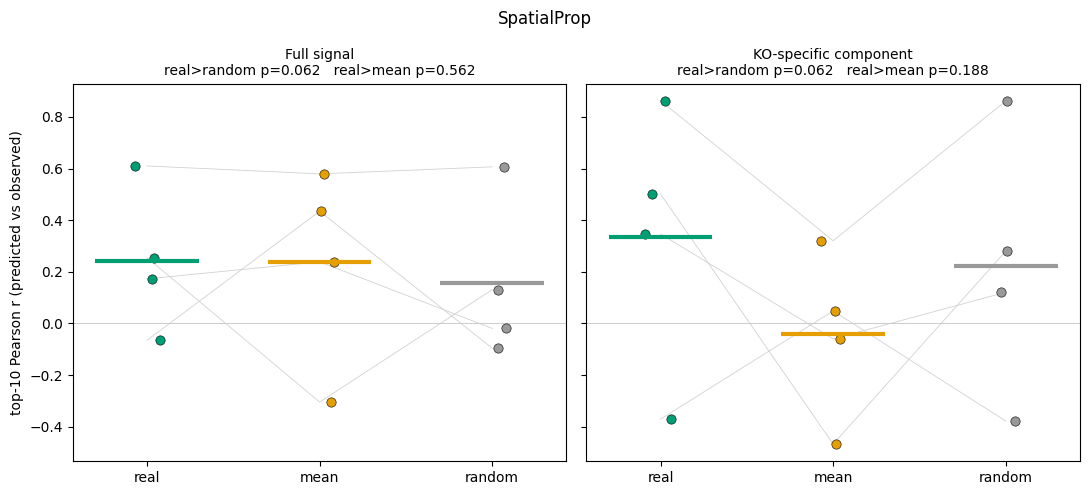

full        : real=0.243  mean=0.237  random=0.156
KO-specific : real=0.335  mean=-0.040  random=0.221


In [11]:
def scores(resid, N=10, EFF9=EFF9):
    tg = {k: (OBS[k] - shared if resid else OBS[k]) for k in EFF9}
    re = [rN(tg[k], REAL5[k], N) for k in EFF9]
    ra = [np.mean([rN(tg[k], rp, N) for rp in RAND]) for k in EFF9]
    me = [rN(tg[k], mean_shift, N) for k in EFF9]
    return np.array(re), np.array(ra), np.array(me)

C = {"real": "#009E73", "mean": "#E69F00", "random": "#999999"}
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for a, (resid, ttl) in zip(ax, [(False, "Full signal"), (True, "KO-specific component")]):
    re, ra, me = scores(resid, EFF9=EFF9_2)
    print(re)
    for j, (v, name) in enumerate([(re, "real"), (me, "mean"), (ra, "random")]):
        a.scatter(np.full(len(v), j) + rng.uniform(-.09, .09, len(v)), v, s=45,
                  color=C[name], edgecolor="k", lw=.4, zorder=3)
        a.hlines(v.mean(), j - .3, j + .3, color=C[name], lw=3, zorder=4)
    for k in range(len(EFF9_2)):
        a.plot([0, 1, 2], [re[k], me[k], ra[k]], color="0.82", lw=.6, zorder=1)
    a.axhline(0, color="0.8", lw=.7); a.set_xticks([0, 1, 2]); a.set_xticklabels(["real", "mean", "random"])
    pr = wilcoxon(re, ra, alternative="greater").pvalue; pm = wilcoxon(re, me, alternative="greater").pvalue
    a.set_title(f"{ttl}\nreal>random p={pr:.3f}   real>mean p={pm:.3f}", fontsize=10)
ax[0].set_ylabel("top-10 Pearson r (predicted vs observed)")
plt.suptitle("SpatialProp"); plt.tight_layout(); plt.show()
for resid, ttl in [(False, "full"), (True, "KO-specific")]:
    re, ra, me = scores(resid, EFF9=EFF9_2); print(f"{ttl:12s}: real={re.mean():.3f}  mean={me.mean():.3f}  random={ra.mean():.3f}")

In [44]:
re

array([ 0.86369421,  0.57908257,  0.60317108, -0.16892218])

In [12]:
recon = adata.X[far]
recon = _normalize_counts(recon)

In [14]:
adata.obs["is_holdout"] = False
adata.obs.iloc[idx_target, adata.obs.columns.get_loc("is_holdout")] = True

In [15]:
import sys

sys.path.append('../../scripts')

from scipy.stats import spearmanr
from counterfactual_analysis import compute_edistance, direction_match, compute_mse_lfc

n_deg = 10
counts_per_k = 1e4
results = []

for k in EFF9_2:
    deg = np.argsort(-np.abs(OBS[k]))[:n_deg]
    lfc_pred = REAL5[k]
    lfc_observed = OBS[k]

    spear, _ = spearmanr(lfc_observed[deg], lfc_pred[deg])
    pear, _ = pearsonr(lfc_observed[deg], lfc_pred[deg])
    dir_match_k = direction_match(lfc_observed[deg], lfc_pred[deg], k=n_deg, normalize="k")
    edist_pca_log = compute_edistance(adata, observed=recon, predicted=COUNTERFACTUALS[k], deg=None, library_size=counts_per_k, local=True, use_pca=True)
    mse_lfc = compute_mse_lfc(gt_vec=lfc_observed, cf_vec=lfc_pred, deg=deg)
    rmse_lfc = np.sqrt(mse_lfc)  # Compute RMSE from MSE of log fold change
    
    results.append({
        "KO": k,
        "Pearson": pear,
        "Spearman": spear,
        "Direction_Match": dir_match_k,
        "E_Distance_PCA_Log": edist_pca_log,
        "RMSE_LFC": rmse_lfc
    })

df_results = pd.DataFrame(results)
df_results['type'] = 'full'
df_results

,KO,Pearson,Spearman,Direction_Match,E_Distance_PCA_Log,RMSE_LFC,type
0,MAP2K2,0.172689,-0.006061,0.6,10.424494,1.024461,full
1,IRAK1,0.255140,0.103030,0.7,10.358368,0.878558,full
2,IRF7,0.610136,0.648485,0.6,10.352994,0.721358,full
3,PELI1,-0.065386,-0.042424,0.6,10.380737,0.957564,full


In [16]:
n_deg = 10
counts_per_k = 1e4
ko_results = []

for k in EFF9_2:
    deg = np.argsort(-np.abs(OBS[k]))[:n_deg]
    lfc_pred = REAL5[k]
    lfc_observed = OBS[k] - shared

    spear, _ = spearmanr(lfc_observed[deg], lfc_pred[deg])
    pear, _ = pearsonr(lfc_observed[deg], lfc_pred[deg])
    dir_match_k = direction_match(lfc_observed[deg], lfc_pred[deg], k=n_deg, normalize="k")
    edist_pca_log = compute_edistance(adata, observed=recon, predicted=COUNTERFACTUALS[k], deg=None, library_size=counts_per_k, local=True, use_pca=True)
    mse_lfc = compute_mse_lfc(gt_vec=lfc_observed, cf_vec=lfc_pred, deg=deg)
    rmse_lfc = np.sqrt(mse_lfc)  # Compute RMSE from MSE of log fold change
    
    ko_results.append({
        "KO": k,
        "Pearson": pear,
        "Spearman": spear,
        "Direction_Match": dir_match_k,
        "E_Distance_PCA_Log": edist_pca_log,
        "RMSE_LFC": rmse_lfc
    })

# Append results list (rows) to results_df
ko_results = pd.DataFrame(ko_results)
ko_results['type'] = 'KO-specific'
df_results = pd.concat([df_results, ko_results], ignore_index=True)
df_results

,KO,Pearson,Spearman,Direction_Match,E_Distance_PCA_Log,RMSE_LFC,type
0,MAP2K2,0.172689,-0.006061,0.6,10.424494,1.024461,full
1,IRAK1,0.255140,0.103030,0.7,10.358368,0.878558,full
2,IRF7,0.610136,0.648485,0.6,10.352994,0.721358,full
3,PELI1,-0.065386,-0.042424,0.6,10.380737,0.957564,full
4,MAP2K2,0.233009,0.212121,0.6,10.450706,0.963263,KO-specific
5,IRAK1,0.217337,-0.090909,0.7,10.569646,0.857289,KO-specific
6,IRF7,0.540794,0.684848,0.6,10.448169,0.770725,KO-specific
7,PELI1,-0.098316,-0.042424,0.6,10.645165,0.980904,KO-specific


In [20]:
metrics = ['Pearson', 'Spearman', 'Direction_Match', 'E_Distance_PCA_Log', 'RMSE_LFC']

summary = df_results.groupby('type')[metrics].agg(['mean', 'std'])

# Nicely formatted mean±std strings
summary_fmt = df_results.groupby('type')[metrics].agg(lambda x: f"{x.mean():.2f} ± {x.std():.2f}")
print(summary_fmt)

                 Pearson     Spearman Direction_Match E_Distance_PCA_Log  \
type                                                                       
KO-specific  0.22 ± 0.26  0.19 ± 0.36     0.62 ± 0.05       10.53 ± 0.10   
full         0.24 ± 0.28  0.18 ± 0.32     0.62 ± 0.05       10.38 ± 0.03   

                RMSE_LFC  
type                      
KO-specific  0.89 ± 0.10  
full         0.90 ± 0.13  


### 4.4 Strong-gene robustness

Same sweep as the Cellina notebook: signal concentration in the strongest-shifted
genes vs the full 154-gene panel.

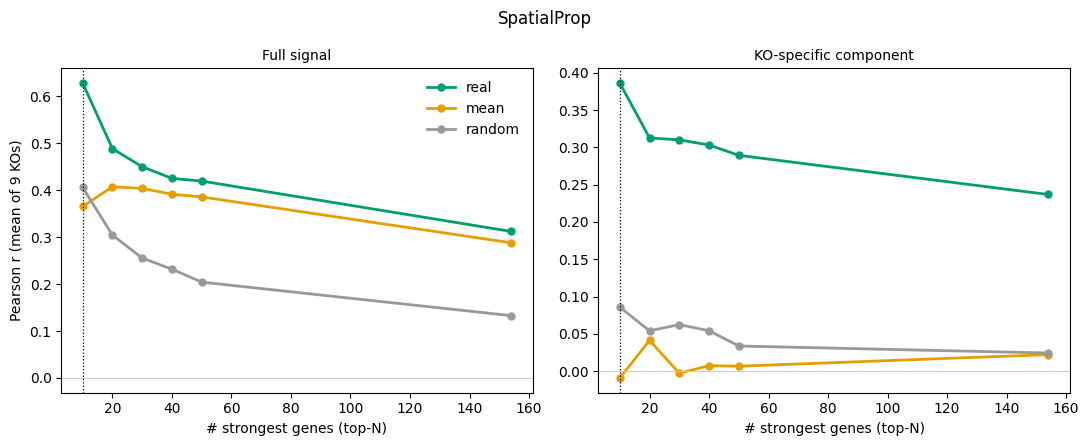

In [11]:
Ns = [10, 20, 30, 40, 50, 154]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a, (resid, ttl) in zip(ax, [(False, "Full signal"), (True, "KO-specific component")]):
    for name in ["real", "mean", "random"]:
        ys = []
        for N in Ns:
            re, ra, me = scores(resid, N)
            ys.append({"real": re, "mean": me, "random": ra}[name].mean())
        a.plot(Ns, ys, "-o", color=C[name], lw=2, ms=5, label=name)
    a.axvline(10, color="k", ls=":", lw=.9); a.axhline(0, color="0.8", lw=.7)
    a.set_xlabel("# strongest genes (top-N)"); a.set_title(ttl, fontsize=10)
ax[0].set_ylabel("Pearson r (mean of 9 KOs)"); ax[0].legend(frameon=False)
plt.suptitle("SpatialProp"); plt.tight_layout(); plt.show()

### 4.5 Dose-response

Purely data-derived (no model prediction involved on either side) — identical
computation to the Cellina notebook §4.5, reused verbatim as a shared point of
reference between the two analyses.

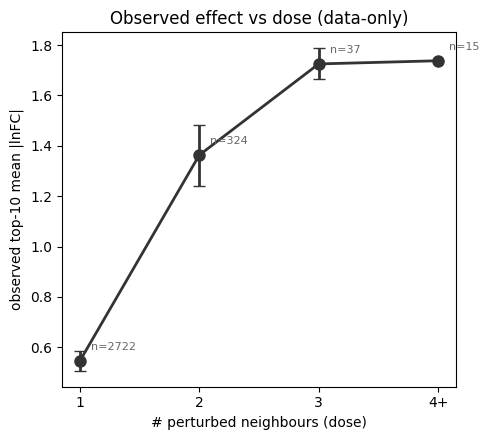

In [12]:
DOSES = [("1", lambda d: d == 1), ("2", lambda d: d == 2), ("3", lambda d: d == 3), ("4+", lambda d: d >= 4)]
X = {"1": 1, "2": 2, "3": 3, "4+": 4}
Abin = (conn > 0).astype(float)
rec = []
for ko in EFF9:
    npk = np.asarray(Abin.dot((pc & (pert == ko)).astype(float))).ravel()
    noth = np.asarray(conn.dot((pc & (pert != ko)).astype(float))).ravel() > 0
    for lab, f in DOSES:
        t = np.where(uT & f(npk) & ~noth)[0]
        if len(t) < 15:
            continue
        ob = lfc(pn(counts[t]), pn(counts[match(t, far)]))
        rec.append(dict(x=X[lab], n=len(t), mag=np.abs(ob)[np.argsort(-np.abs(ob))[:10]].mean()))
dd = pd.DataFrame(rec)
g = dd.groupby("x").agg(m=("mag", "mean"), se=("mag", lambda v: v.std() / max(1, np.sqrt(len(v)))), n=("n", "sum"))
plt.figure(figsize=(5, 4.5))
plt.errorbar(g.index, g.m, yerr=g.se, fmt="-o", color="#333", lw=2, ms=8, capsize=4)
for x, r in g.iterrows():
    plt.annotate(f"n={int(r.n)}", (x, r.m), textcoords="offset points", xytext=(8, 8), fontsize=8, color="0.4")
plt.xticks([1, 2, 3, 4], ["1", "2", "3", "4+"]); plt.xlabel("# perturbed neighbours (dose)")
plt.ylabel("observed top-10 mean |lnFC|"); plt.title("Observed effect vs dose (data-only)"); plt.tight_layout(); plt.show()

## 5. Interpretation

- **Perturbations act cell-intrinsically** — same 9/35 KOs as the Cellina
  analysis have a real direct effect on their own cancer cell (§4.1, data-only,
  shared between both notebooks).
- **Real vs random vs mean** (§4.3–4.4) — read off the printed statistics above:
  does the KO *identity* of the injected signature matter (real > random), and
  does it survive once the shared tumour-region confound is removed (real >
  mean on the KO-specific component)?
- **Dose-response** (§4.5) is identical in both notebooks by construction (it's
  purely a property of the observed data) — included here so the two notebooks
  are readable independently, not as a new result.
- **Mechanism difference worth remembering when comparing the two models'
  numbers**: SpatialProp's counterfactual here perturbs *every* cancer cell in
  the tissue and lets the GNN read off each far T cell's *true* fraction of
  perturbed neighbours, whereas Cellina's headline result inserts a *saturating*
  (100%-occupancy) synthetic niche. Per Cellina's own §4.6, its dosed/true-occupancy
  variant is "far weaker, near the noise floor" than its saturating insertion — so
  a weaker signal here is not necessarily evidence SpatialProp propagates
  perturbations less well; it may simply reflect that this notebook exercises the
  more realistic, harder, lower-dose regime of the intervention rather than the
  saturating one. A fairer apples-to-apples comparison would need Cellina's own
  dosed/node-perturbation result (§4.6 there) rather than its saturating
  insertion (§4.2–4.5) as the reference point.